## Correlation Analysis

In this notebook we will be looking over the data computed from the NTL analysis to see what relation, if any exists, between our predictors and the target data (% houses completely damaged).

The follow _**correlations**_ will be explored for this data:
- `Spearman Correlation (𝝆)`
- `Pearson Correlation (r)`

The results here may inform an update to the processing of the data for the predictive modeling phase, and help us determine the potential usefulness of the NTL metrics where we don't have ground truth data as an indicator for where help may be needed.

**Import needed libraries and data**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
%load_ext autoreload
%autoreload 2

from helper_functions import *

plt.rcParams['font.family'] = 'Helvetica'

BACKGROUND_COLOR = '#EAF2EF'

thesis_cmap_div = mcolors.LinearSegmentedColormap.from_list(
    "thesis_div",
    [
        '#F6511D',  # orange red
        '#EAF2EF',  # off white
        '#097FC7',  # ocean blue
    ]
)

**Read in the Needed Data**

In [ ]:
# read in the data from before
X_train_simp = pd.read_csv('../data/csvs/simplified_X_train_data.csv')
X_test_simp = pd.read_csv('../data/csvs/simplified_X_test_data.csv')

# join the train and test sets together for easier computation
X_simp = pd.concat([X_train_simp,X_test_simp])

final_df = pd.read_csv('../data/target/model_training_data_final.csv')
final_with_landcov = pd.read_csv('../data/target/model_training_data_final_with_lc.csv')
final_only_urban = pd.read_csv('../data/target/model_training_data_final_urban_only.csv')

X_final = final_df.drop(columns=['percent_houses_damaged_5years','percent_houses_damaged'])
X_lc = final_with_landcov.drop(columns=['percent_houses_damaged_5years','percent_houses_damaged','typhoon_name'])
X_urban = final_only_urban.drop(columns=['percent_houses_damaged_5years','percent_houses_damaged'])

y_final = final_df['percent_houses_damaged']
y_lc = final_with_landcov['percent_houses_damaged']
y_urban = final_only_urban['percent_houses_damaged']

X_train_f, X_test_f, y_train_f, y_test_f = clean_and_split_data(final_df, ['percent_houses_damaged_5years','percent_houses_damaged'], 
                    'percent_houses_damaged', filling_method='complex', remove_corr_cols=False, thresh=0.75)
X_train_lc, X_test_lc, y_train_lc, y_test_lc = clean_and_split_data(final_with_landcov, ['percent_houses_damaged_5years','percent_houses_damaged'], 
                     'percent_houses_damaged', filling_method='complex', remove_corr_cols=False, thresh=0.75)
X_train_ur, X_test_ur, y_train_ur, y_test_ur = clean_and_split_data(final_only_urban, ['percent_houses_damaged_5years','percent_houses_damaged'], 
                     'percent_houses_damaged', filling_method='complex', remove_corr_cols=False, thresh=0.75)

X_f = pd.concat([X_train_f,X_test_f])
y_f = pd.concat([y_train_f, y_test_f])

X_lc = pd.concat([X_train_lc, X_test_lc])
y_lc = pd.concat([y_train_lc, y_test_lc])

X_ur = pd.concat([X_train_ur, X_test_ur])
y_ur = pd.concat([y_train_ur, y_test_ur])

Start looking into the correlations and distributions:

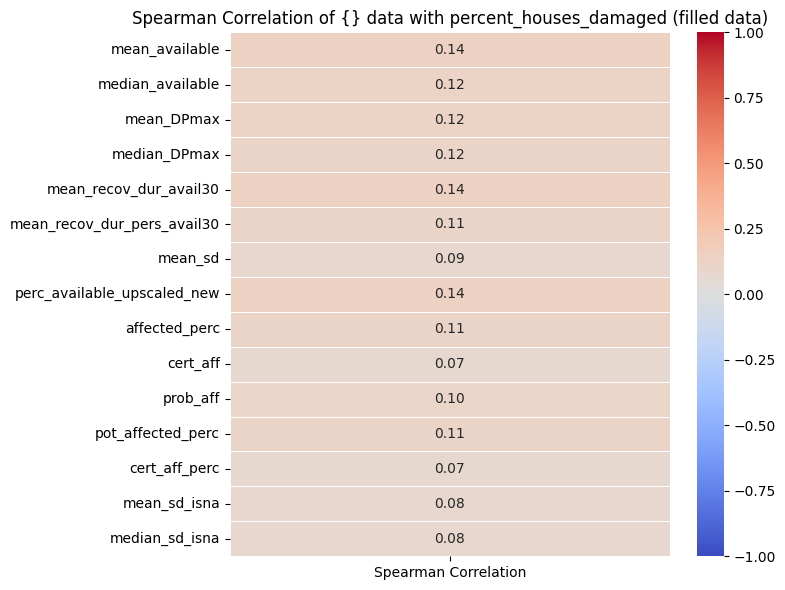

In [7]:
get_highest_corrs_with_target_plot(X_f,y_f,'Final')

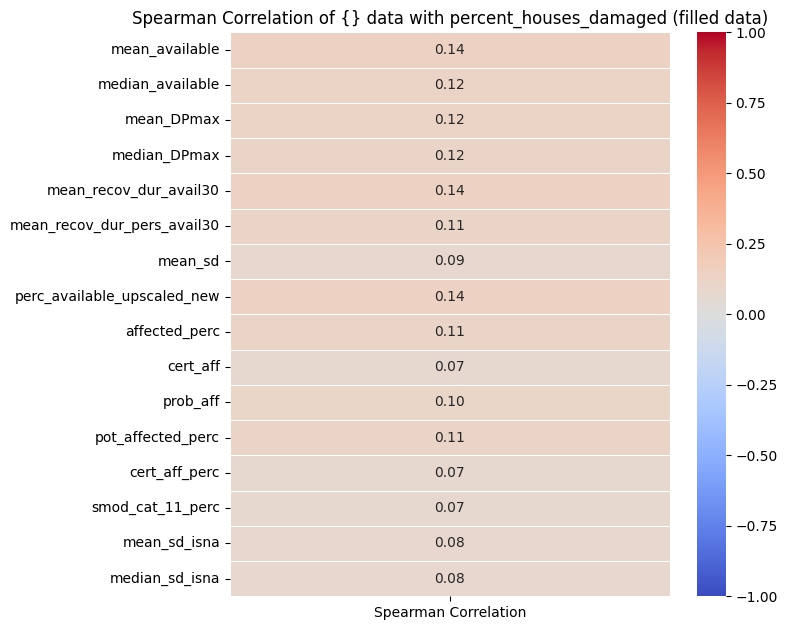

In [8]:
get_highest_corrs_with_target_plot(X_lc,y_lc,'Land Cover')

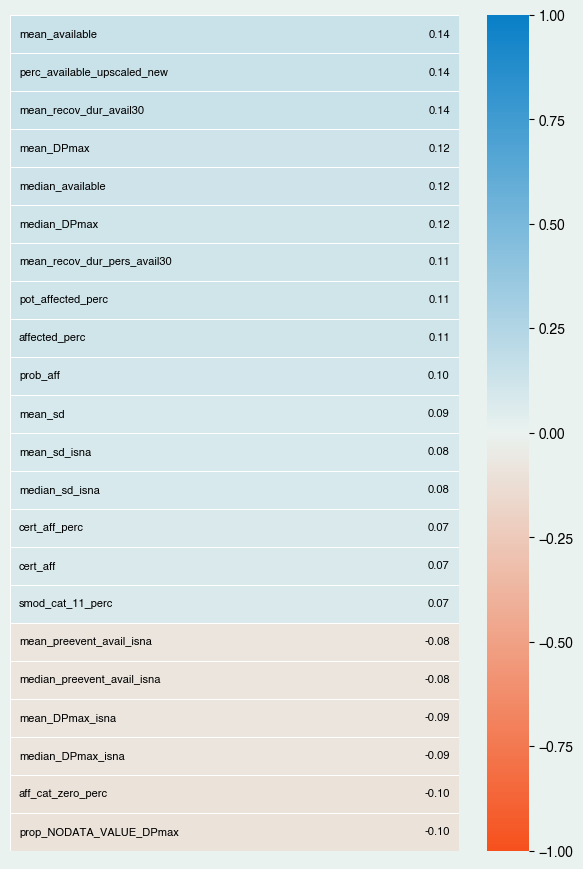

In [ ]:
get_highest_corrs_with_target_plot(X_lc,y_lc,'Land Cover')

In [15]:
#read in the data
df = pd.read_csv('../data/target/model_training_data_new.csv')

#drop the missing storms
na_cols = get_na_columns(df)
bad_storms = find_bad_storms(df, na_cols)
df_clean = df[~df['typhoon_name'].isin(bad_storms)]

#get the correct y and X for the clean data
y_1 = df_clean[['percent_houses_damaged']]
y_2 = df_clean[['percent_houses_damaged_5years']]
X = df_clean.drop(columns=['percent_houses_damaged_5years','percent_houses_damaged'])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y_1, random_state=42)

### Begin Correlation Exploration

/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/pandas/core/nanops.py:1661: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


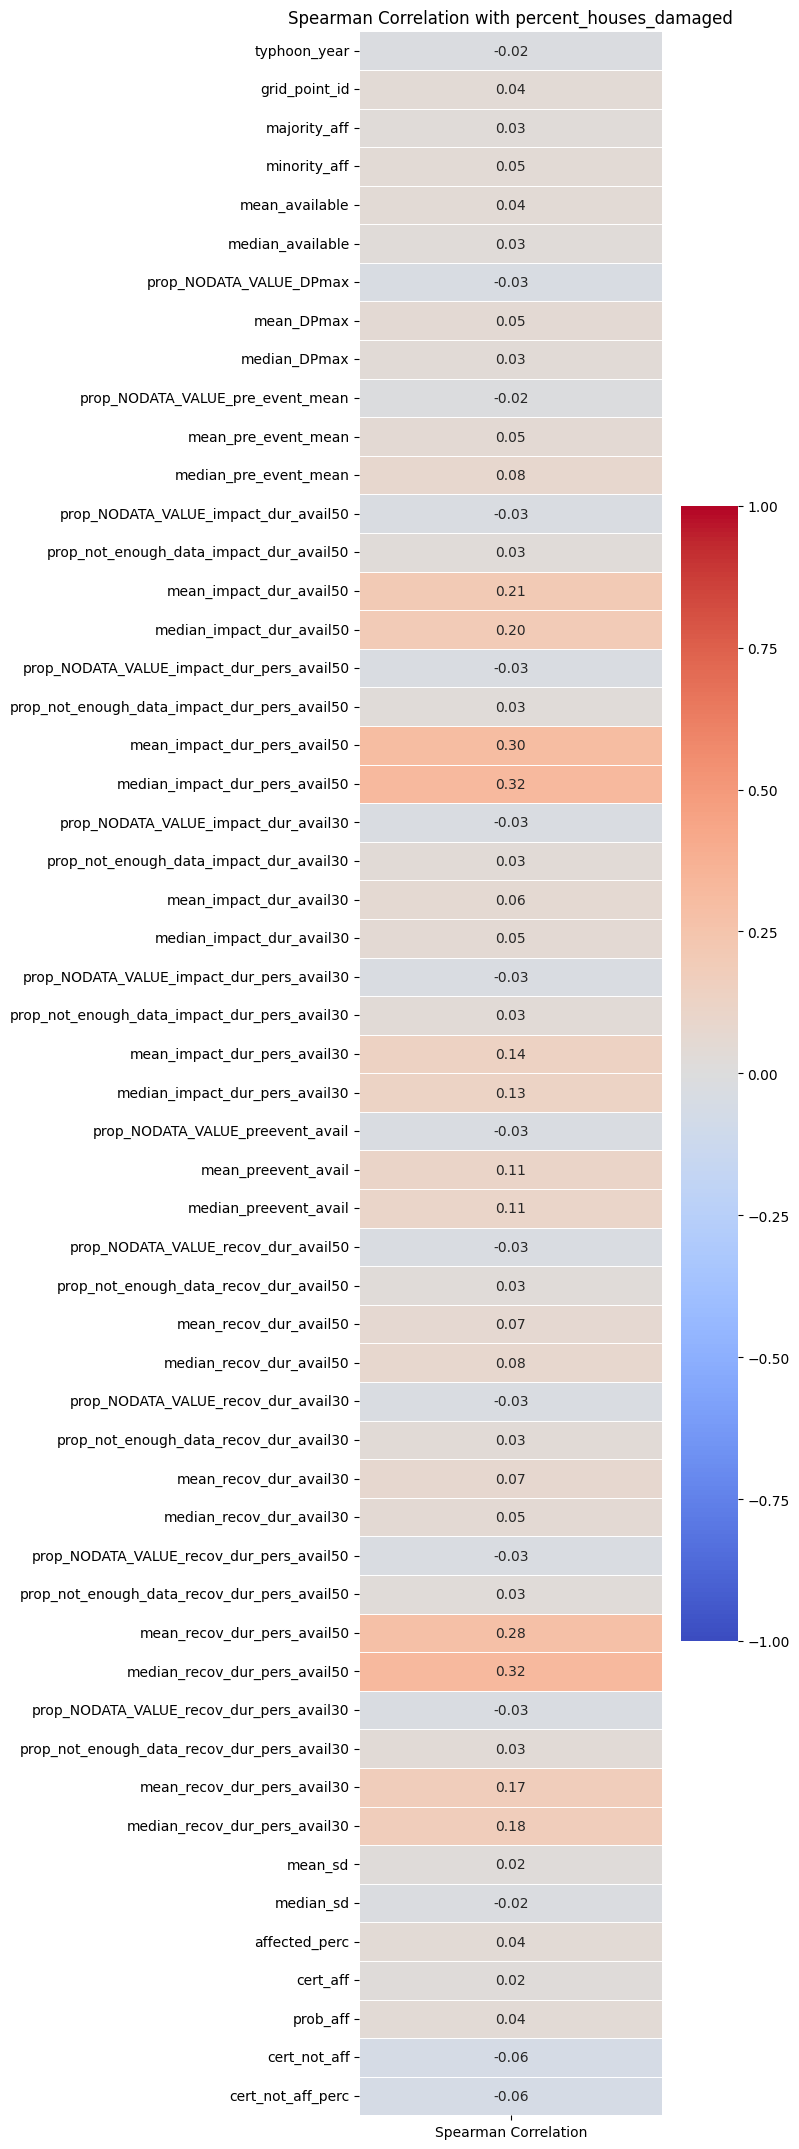

In [87]:
corr_s = X.drop(columns=['typhoon_name']).corrwith(df_clean['percent_houses_damaged'], method='spearman').to_frame(name='Spearman Correlation').dropna()
corr_s_thresh = corr_s[corr_s > 0.2].dropna()

plt.figure(figsize=(8, len(corr_s) * 0.4))
sns.heatmap(
    corr_s,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.title('Spearman Correlation with percent_houses_damaged')
plt.tight_layout()
plt.show()

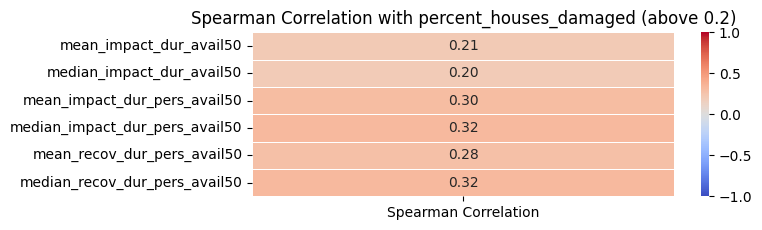

In [89]:
plt.figure(figsize=(8, len(corr_s_thresh) * 0.4))
sns.heatmap(
    corr_s_thresh,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.title('Spearman Correlation with percent_houses_damaged (above 0.2)')
plt.tight_layout()
plt.show()

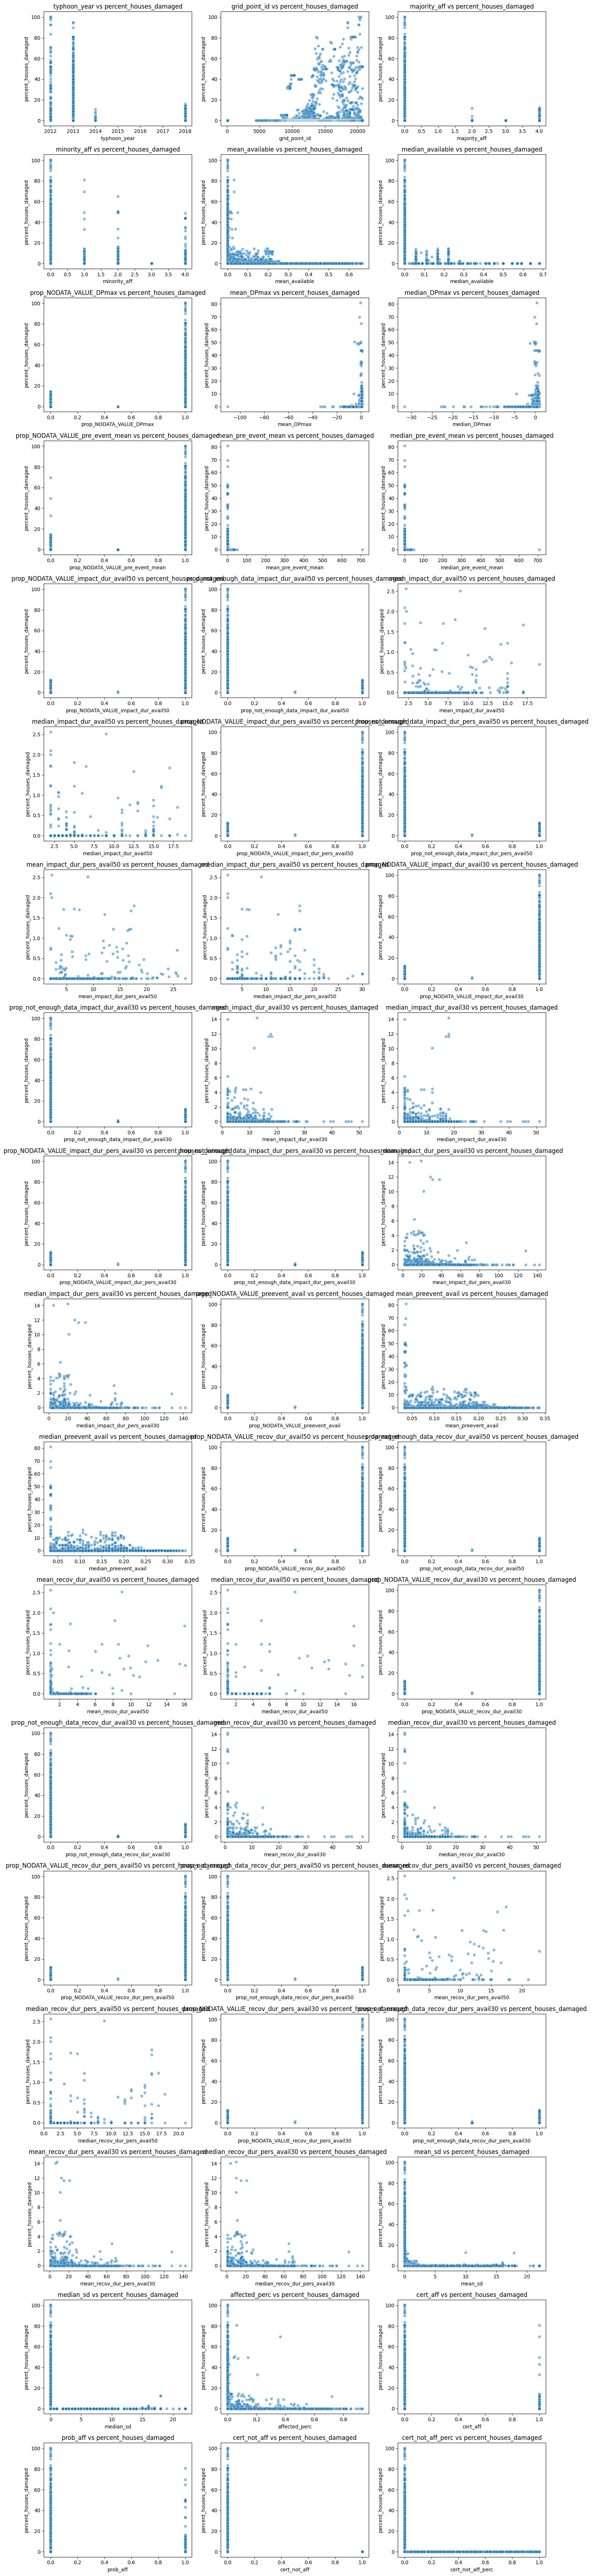

In [46]:
corr_2 = corr > 0.2

features = corr_2.index

n_cols = 3
n_rows = int(np.ceil(len(features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.scatterplot(
        x=X[feature],
        y=df_clean['percent_houses_damaged'],
        alpha=0.5,
        ax=axes[i]
    )
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('percent_houses_damaged')
    axes[i].set_title(f'{feature} vs percent_houses_damaged')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [21]:
df_clean.drop(columns=['typhoon_name']).corr(method='spearman')[['percent_houses_damaged']]

,percent_houses_damaged
typhoon_year,-0.019994
grid_point_id,0.042863
percent_houses_damaged,1.000000
percent_houses_damaged_5years,-0.046881
prop_NODATA_VALUE_aff,NaN
...,...
affected_perc,0.044099
cert_aff,0.020423
prob_aff,0.043845
cert_not_aff,-0.060161


Pearsons:

In [81]:
corr_p[corr_p > 0.2].dropna()

,Pearson Correlation
mean_recov_dur_avail50,0.329164
median_recov_dur_avail50,0.306439
mean_recov_dur_pers_avail50,0.271578
median_recov_dur_pers_avail50,0.291719


/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


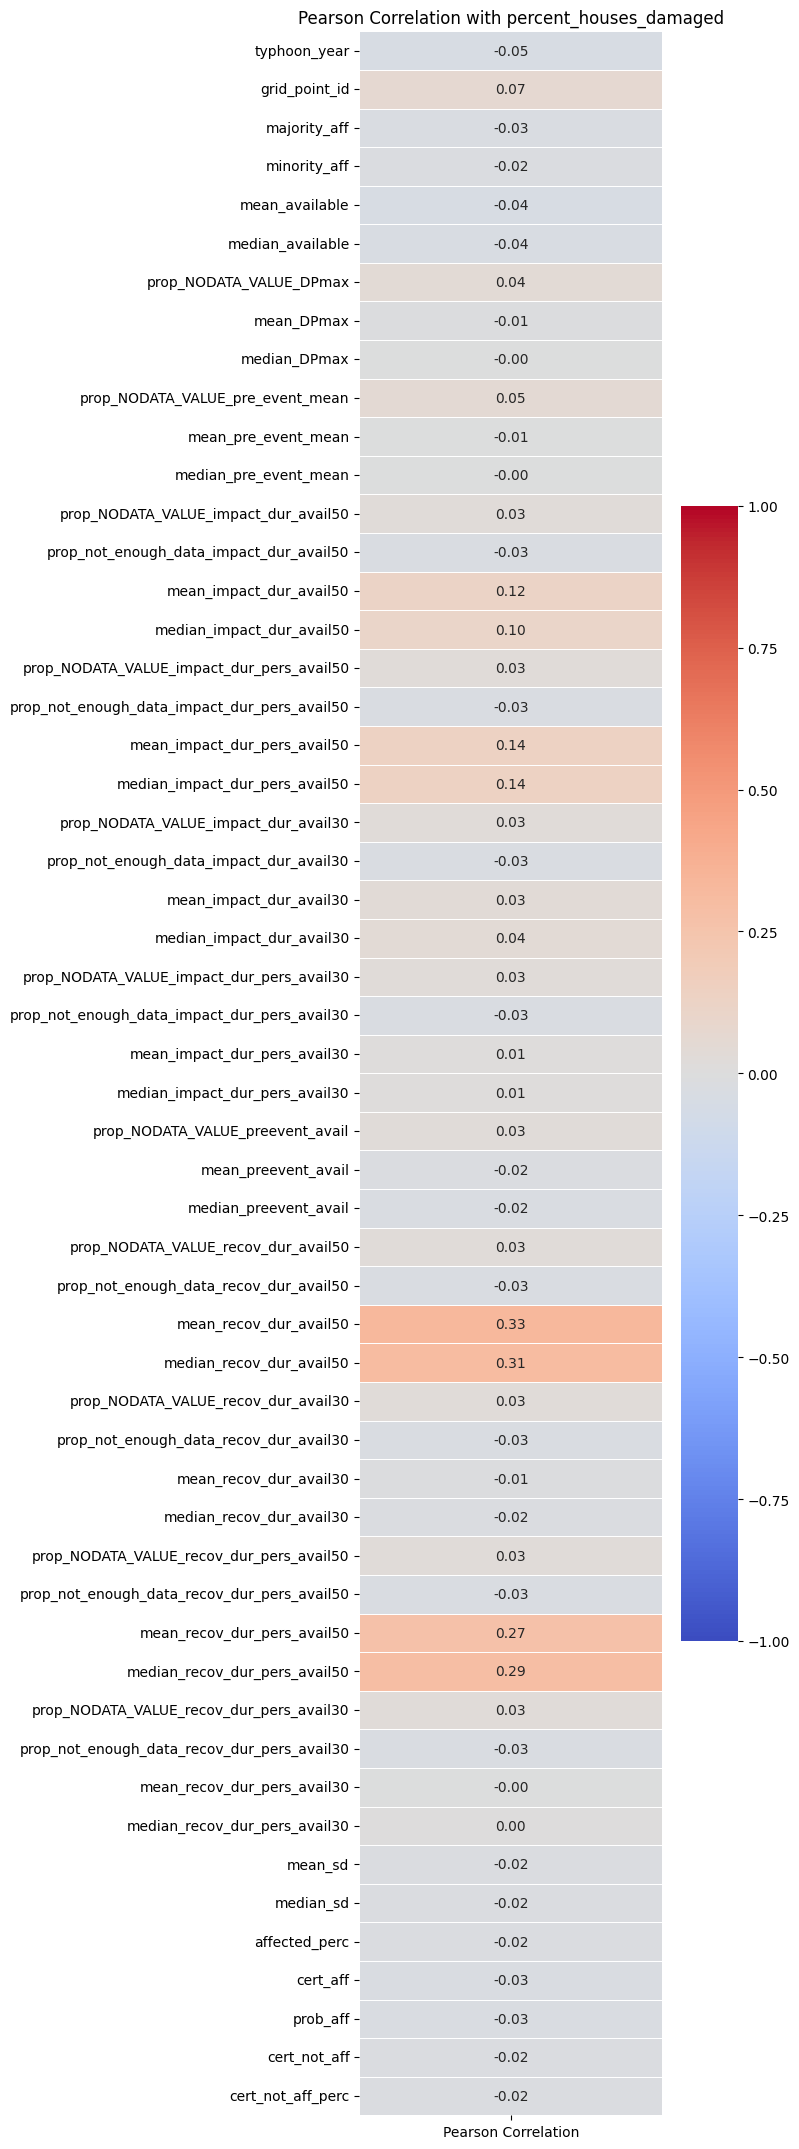

In [85]:
corr_p = X.drop(columns=['typhoon_name']).corrwith(df_clean['percent_houses_damaged'], method='pearson').to_frame(name='Pearson Correlation').dropna()
corr_p_thresh = corr_p[corr_p > 0.2].dropna()

plt.figure(figsize=(8, len(corr) * 0.4))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.title('Pearson Correlation with percent_houses_damaged')
plt.tight_layout()
plt.show()

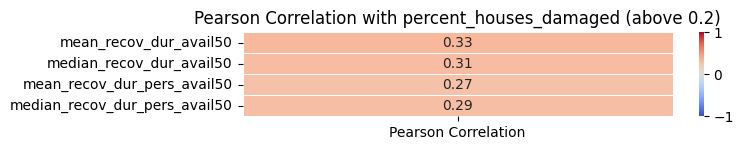

In [86]:
plt.figure(figsize=(8, len(corr_p_thresh) * 0.4))
sns.heatmap(
    corr_p_thresh,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.title('Pearson Correlation with percent_houses_damaged (above 0.2)')
plt.tight_layout()
plt.show()

In [52]:
corr_p = X.drop(columns=['typhoon_name']).corrwith(df_clean['percent_houses_damaged'], method='pearson').dropna()
corr_sp = X.drop(columns=['typhoon_name']).corrwith(df_clean['percent_houses_damaged'], method='spearman').dropna()


/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/pandas/core/nanops.py:1661: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


In [63]:
df_p = pd.DataFrame(corr_p).reset_index().rename(columns={'index':'column_names',0:'pearson_corr'})
df_sp = pd.DataFrame(corr_sp).reset_index().rename(columns={'index':'column_names',0:'spearman_corr'})

In [70]:
corr_comp = df_p.merge(df_sp,how='left',on="column_names")

corr_comp['spear_higher'] = corr_comp.pearson_corr.abs() < corr_comp.spearman_corr.abs()
corr_comp['pear_higher'] = corr_comp.pearson_corr.abs() > corr_comp.spearman_corr.abs()

In [74]:
corr_comp[corr_comp["pear_higher"]]

,column_names,pearson_corr,spearman_corr,spear_higher,pear_higher
0,typhoon_year,-0.045435,-0.019994,False,True
1,grid_point_id,0.067726,0.042863,False,True
2,majority_aff,-0.025898,0.025872,False,True
5,median_available,-0.038578,0.025134,False,True
6,prop_NODATA_VALUE_DPmax,0.042968,-0.034318,False,True
9,prop_NODATA_VALUE_pre_event_mean,0.052403,-0.015548,False,True
33,mean_recov_dur_avail50,0.329164,0.068209,False,True
34,median_recov_dur_avail50,0.306439,0.078831,False,True
47,mean_sd,-0.022442,0.021582,False,True
48,median_sd,-0.018051,-0.015809,False,True


In [75]:
corr_comp[["spear_higher","pear_higher"]].sum()

spear_higher    43
pear_higher     11
dtype: int64

Clean the data to see how the correlations compare after:

In [4]:
#read in the data
df = pd.read_csv('../data/target/model_training_data_new.csv')

#drop the missing storms
na_cols = get_na_columns(df)
bad_storms = find_bad_storms(df, na_cols)
df_clean = df[~df['typhoon_name'].isin(bad_storms)]

#get the correct y and X for the clean data
y_1 = df_clean[['percent_houses_damaged']]
y_2 = df_clean[['percent_houses_damaged_5years']]
X = df_clean.drop(columns=['percent_houses_damaged_5years','percent_houses_damaged'])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y_1, random_state=42)

In [123]:
na_columns = get_na_columns(X)

In [91]:
na_columns = get_na_columns(X)
median_dict = calculate_storm_medians(X_train, na_columns)

# now applying these to both the train and test set, so we can impute the nulls with the storm-specific medians
for col in na_columns:
    # only impute where null — preserve existing values
    null_mask_train = X_train[col].isna()
    null_mask_test = X_test[col].isna()

    X_train.loc[null_mask_train, col] = X_train[null_mask_train].apply(
        lambda row: get_storm_median_for_row(row, median_dict, col), axis=1
    )
    X_test.loc[null_mask_test, col] = X_test[null_mask_test].apply(
        lambda row: get_storm_median_for_row(row, median_dict, col), axis=1
    )

In [112]:
# concat the data to be one dataframe
X = pd.concat([X_train,X_test])
y = pd.concat([y_train,y_test])

# drop columns that only have one value and therefore don't provide value
cols_to_drop = []
for col in X.columns:
    if X[col].value_counts().shape[0] == 1:
        cols_to_drop.append(col)
    
X.drop(columns=cols_to_drop, inplace=True)

df_filled= pd.concat([X, y], axis=1)


Now look at the same correlations to see how they look now with the updates:

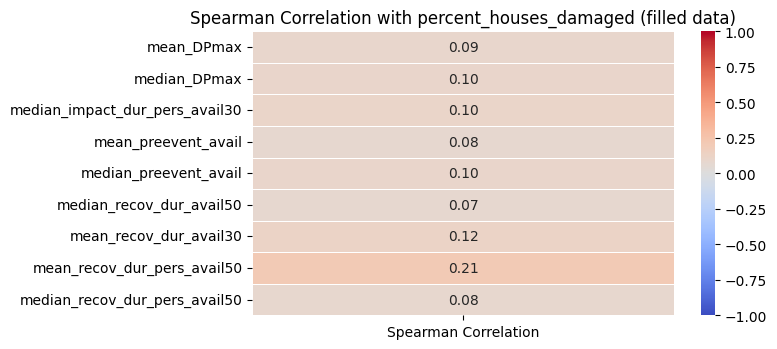

In [113]:
corr_s_update = df_filled.drop(columns=['typhoon_name','percent_houses_damaged']).corrwith(df_filled["percent_houses_damaged"], method='spearman').to_frame(name='Spearman Correlation').dropna()
corr_s_thresh_up = corr_s_update[corr_s_update > 0.07].dropna()

plt.figure(figsize=(8, len(corr_s_thresh_up) * 0.4))
sns.heatmap(
    corr_s_thresh_up,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.title('Spearman Correlation with percent_houses_damaged (filled data)')
plt.tight_layout()
plt.show()

/var/folders/xw/1pm761sd11b96_3c77wx1b900000gn/T/ipykernel_21961/1774143942.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


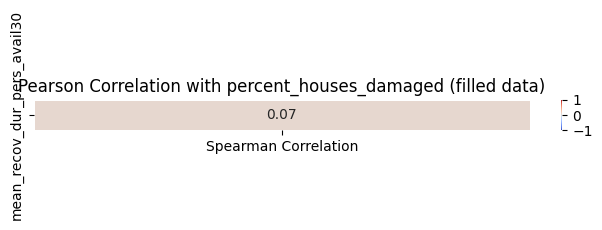

In [118]:
corr_p_update = df_filled.drop(columns=['typhoon_name','percent_houses_damaged']).corrwith(df_filled['percent_houses_damaged'], method='pearson').to_frame(name='Spearman Correlation').dropna()
corr_p_thresh_up = corr_p_update[corr_p_update > 0.07].dropna()

plt.figure(figsize=(8, len(corr_p_thresh_up) * 0.4))
sns.heatmap(
    corr_p_thresh_up,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.title('Pearson Correlation with percent_houses_damaged (filled data)')
plt.tight_layout()
plt.show()

Trying this with an updated version with a more basic version of filling nulls:

In [ ]:
# Usage
storm_medians = calculate_storm_medians(X_train, na_columns)
global_medians = X_train[na_columns].median().to_dict()  # fallback for unseen storms

X_train_imputed = impute_with_storm_medians(X_train, storm_medians, na_columns, global_medians)
X_test_imputed  = impute_with_storm_medians(X_test, storm_medians, na_columns, global_medians)

# concat the data to be one dataframe
X_simp = pd.concat([X_train_imputed,X_test_imputed])

# drop columns that only have one value and therefore don't provide value
cols_to_drop = []
for col in X_simp.columns:
    if X_simp[col].value_counts().shape[0] == 1:
        cols_to_drop.append(col)
    
X_simp.drop(columns=cols_to_drop, inplace=True)

df_filled_simp = pd.concat([X_simp, y], axis=1)

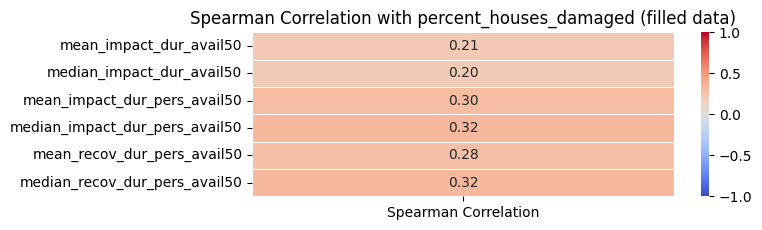

In [127]:
corr_s_update_2 = df_filled_simp.drop(columns=['typhoon_name','percent_houses_damaged']).corrwith(df_filled_simp['percent_houses_damaged'], method='spearman').to_frame(name='Spearman Correlation').dropna()
corr_s_thresh_up_2 = corr_s_update_2[corr_s_update_2 > 0.2].dropna()

plt.figure(figsize=(8, len(corr_s_thresh_up_2) * 0.4))
sns.heatmap(
    corr_s_thresh_up_2,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.title('Spearman Correlation with percent_houses_damaged (filled data)')
plt.tight_layout()
plt.show()

Ok, this method has kept the correlations stronger. Need to think about this more. Is there something here about the storm type etc that is causing this. Maybe need to explor the effected tag a bit more and the nulls that are related to this and the impacted data that we have for this.

There are so many nulls, we need to see how the columns relate if we only have non-zero targets. 

In [ ]:
# check if any features correlate with non-zero damage at all
nonzero_mask = y_train > 0
corrs = X_train[nonzero_mask].corrwith(y_train[nonzero_mask]).abs().sort_values(ascending=False)
# print(corrs.head(20))

pd.DataFrame(corrs.iloc[:20,]).rename(columns={0:'corr'})

,corr
affected_perc,NaN
cert_aff,NaN
cert_not_aff,NaN
cert_not_aff_perc,NaN
grid_point_id,NaN
majority_aff,NaN
mean_DPmax,NaN
mean_available,NaN
mean_impact_dur_avail30,NaN
mean_impact_dur_avail50,NaN


In [26]:
nonzero_mask = y_train > 0
corrs = X_train[nonzero_mask].corrwith(y_train[nonzero_mask]).abs()
corrs = corrs.sort_values(ascending=False, na_position='last')
corrs = corrs[:20]

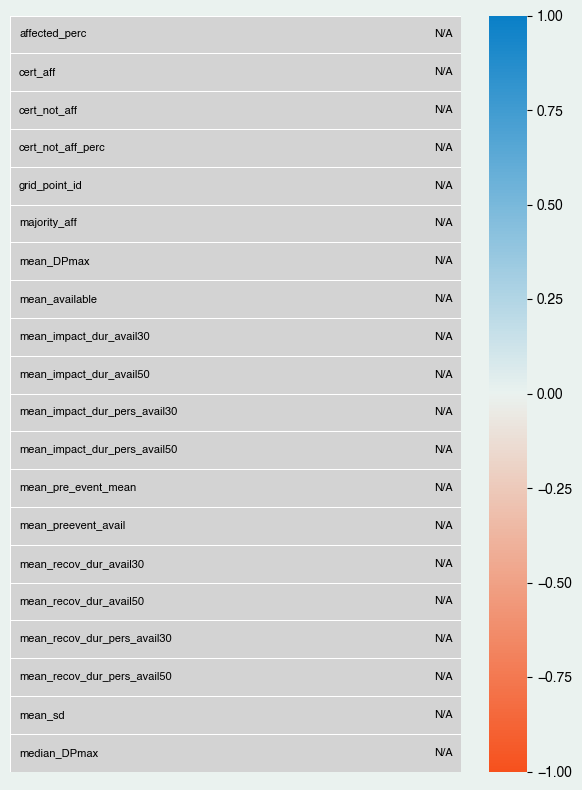

In [48]:
BACKGROUND_COLOR = '#eaf2ef'
plt.rcParams['font.family'] = 'Helvetica'
plot_data = corrs_nonzero['corr'].copy()
nan_mask = plot_data.isna()
plot_data = plot_data.fillna(999).astype(float).to_frame()
#eaf2ef

# custom cmap that maps 999 → grey
from matplotlib.colors import BoundaryNorm
cmap_with_grey = thesis_cmap_div
cmap_with_grey.set_bad(color='lightgrey')

plot_data_masked = np.ma.masked_where(
    nan_mask.values.reshape(-1, 1), 
    plot_data.values
)

fig, ax = plt.subplots(figsize=(6, len(corrs_nonzero) * 0.4), facecolor=BACKGROUND_COLOR)

sns.heatmap(
    plot_data.where(~nan_mask.values.reshape(-1,1)),  # NaN stays NaN
    annot=False,
    cmap=cmap_with_grey,
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='white',
    xticklabels=False,
    yticklabels=False,
    ax=ax,
)

for i, col in enumerate(corrs_nonzero.index):
    val = corrs_nonzero.loc[col, 'corr']
    is_nan = pd.isna(val)
    text_color = 'white' if not is_nan and abs(val) > 0.6 else 'black'
    val_str = 'N/A' if is_nan else f'{val:.2f}'
    ax.text(0.02, i + 0.5, col, ha='left', va='center', fontsize=8, color=text_color, zorder=3)
    ax.text(0.98, i + 0.5, val_str, ha='right', va='center', fontsize=8, fontweight='bold', color=text_color, zorder=3)

ax.set_facecolor(BACKGROUND_COLOR)
ax.set_xlabel('')
ax.set_ylabel('')
# plt.title('Spearman Correlation with percent_houses_damaged (non-zero rows)')
plt.tight_layout()
plt.show()

In [ ]:
nonzero_mask = y_train > 0
print("Non-zero target rows:", nonzero_mask.sum())
print("\nNull counts on non-zero rows:")
print(X_train[nonzero_mask].isna().sum().sort_values(ascending=False).head(20))
print("\nConstant columns on non-zero rows:")
print(X_train[nonzero_mask].nunique().sort_values().head(20))

In [51]:
# read in the target file and filter to the columns we need for the model training
target_cols = ['typhoon_name', 'typhoon_year', 'grid_point_id','percent_houses_damaged','percent_houses_damaged_5years']
target = pd.read_csv('../data/target/new_model_training_dataset.csv')

target_impact = target[target['percent_houses_damaged'] > 0].drop(columns=['typhoon_name'])

target_corrs = target_impact.corr()['percent_houses_damaged'] 

# target_corrs[abs(target_corrs) >= 0.1].sort_values(ascending=False)

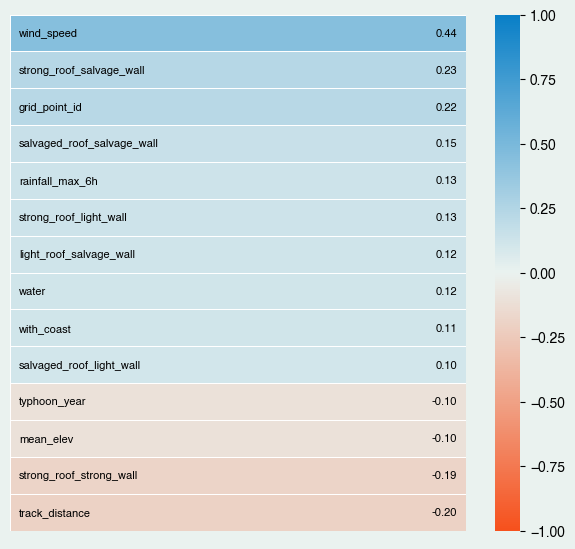

In [53]:
BACKGROUND_COLOR = '#eaf2ef'
plt.rcParams['font.family'] = 'Helvetica'

# prep data
corrs_to_plot = plot_data.sort_values(ascending=False).drop('percent_houses_damaged', errors='ignore')
nan_mask = corrs_to_plot.isna()

plot_df = corrs_to_plot.fillna(np.nan).to_frame(name='corr')

cmap_with_grey = thesis_cmap_div
cmap_with_grey.set_bad(color='lightgrey')

fig, ax = plt.subplots(figsize=(6, len(corrs_to_plot) * 0.4), facecolor=BACKGROUND_COLOR)

sns.heatmap(
    plot_df.where(~nan_mask.values.reshape(-1, 1)),
    annot=False,
    cmap=cmap_with_grey,
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='white',
    xticklabels=False,
    yticklabels=False,
    ax=ax,
)

for i, col in enumerate(corrs_to_plot.index):
    val = corrs_to_plot.loc[col]
    is_nan = pd.isna(val)
    text_color = 'white' if not is_nan and abs(val) > 0.6 else 'black'
    val_str = 'N/A' if is_nan else f'{val:.2f}'
    ax.text(0.02, i + 0.5, col, ha='left', va='center', fontsize=8, color=text_color, zorder=3)
    ax.text(0.98, i + 0.5, val_str, ha='right', va='center', fontsize=8, fontweight='bold', color=text_color, zorder=3)

ax.set_facecolor(BACKGROUND_COLOR)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()